<a href="https://colab.research.google.com/github/nolszewska135/Sztuczna-Inteligencja/blob/main/lab3_21193.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Biblioteka numpy ułatwia pracę z macierzami i wielowymiarowymi tabelami.
import numpy as np
# Biblioteka Tensorflow posłuży nam do zbudowania modelu
import tensorflow as tf
# Biblioteka opencv-python
import cv2
# Wizualizacja danych.
# biblioteka typu open source do przetwarzania obrazu i uczenia maszynowego.
import matplotlib.pyplot as plt
# TensorFlow zawiera dostawcę danych dla MNIST, z którego będziemy korzystać.
import tensorflow_datasets as tfds

In [6]:
# tfds.load ładuje lub pobiera zestaw danych MNIST
# with_info=True dostarczy informacje o wersji i liczbie próbek
# as_supervised=True załaduje dane w strukturze (wejście, cel)
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)

# Wyodrębnienie zestawu treningowego i testowego
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

# Definiujemy liczbę próbek walidacyjnych jako 10% zbioru trenującego
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

# Zapisujemy liczbę próbek testowych
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

In [7]:
# Funkcja scale konwertuje piksele (0-255) na wartości (0.0-1.0)
def scale(image, label):
    image = tf.cast(image, tf.float32)
    image /= 255.
    return image, label

# Mapujemy funkcję skalującą na dane treningowe i testowe
scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)


In [8]:
BUFFER_SIZE = 1000
# Mieszamy dane z określonym rozmiarem bufora
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

# Wyodrębniamy dane walidacyjne (10% całości)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
# Pozostałe dane stają się zestawem treningowym
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

# Określamy wielkość partii (Batch size)
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

# Pobieramy i iterujemy partię walidacyjną (do późniejszego sprawdzenia kształtu)
validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [9]:
# Ustawienie rozmiarów
input_size = 784 # 28x28 pikseli
output_size = 10 # 10 różnych cyfr (0-9)
hidden_layer_size = 50 # rozmiar warstw ukrytych

# Budowa modelu
model = tf.keras.Sequential([
    # Warstwa wejściowa: spłaszcza obraz 28x28x1 do wektora 784 elementów
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),

    # Pierwsza warstwa ukryta (Dense) z funkcją aktywacji ReLu
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),

    # Druga warstwa ukryta
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),

    # Warstwa wyjściowa z funkcją Softmax (zwraca prawdopodobieństwo dla każdej z 10 klas)
    tf.keras.layers.Dense(output_size, activation='softmax')
])

# Kompilacja modelu - określenie optymalizatora i funkcji straty
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# ustawiamy ilość epok
NUM_EPOCHS = 30

# ustaw mechanizm wczesnego zatrzymywania, który ochroni nasz model przed przetrenowaniem
# ustawmy patience=2, aby być nieco tolerancyjnym na losowe wzrosty strat walidacji
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

# dopasowujemy model, określając dane treningowe, łączną liczbę epok
# oraz dane walidacyjne, które właśnie stworzyliśmy, w formacie: (INPUTS, TARGETS)
model.fit(train_data, # dane wejściowe trenujące
          epochs=NUM_EPOCHS, # maksymalna ilość epok gdyby wczesne zatrzymanie nie zadziałało
          callbacks=[early_stopping], # mechanizm "early stopping" - zapobieganie przetrenowaniu
          validation_data=(validation_inputs, validation_targets), # dane walidacyjne
          verbose=1 # sposób pokazania treningu modelu
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8812 - loss: 0.4232 - val_accuracy: 0.9350 - val_loss: 0.2152
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9459 - loss: 0.1877 - val_accuracy: 0.9507 - val_loss: 0.1599
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9593 - loss: 0.1409 - val_accuracy: 0.9603 - val_loss: 0.1353
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9668 - loss: 0.1129 - val_accuracy: 0.9655 - val_loss: 0.1238
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9715 - loss: 0.0947 - val_accuracy: 0.9662 - val_loss: 0.1178
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9747 - loss: 0.0827 - val_accuracy: 0.9682 - val_loss: 0.1155
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9787 - loss: 0.0708 - val_accuracy: 0.9685 - val_loss: 0.1090
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9811 - loss: 0.0615 - val_accurac

In [12]:
# Testujemy ostateczną moc predykcyjną modelu na zbiorze testowym
test_loss, test_accuracy = model.evaluate(test_data)

# Możemy zastosować estetyczne formatowanie wyniku
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9679 - loss: 0.1054
Test loss: 0.11. Test accuracy: 96.79%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


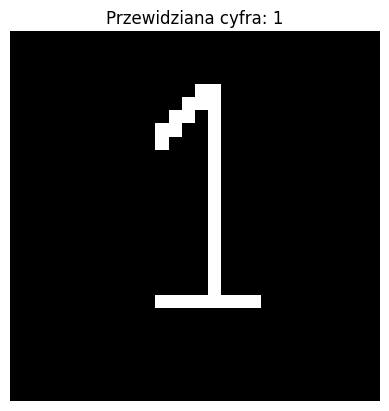

Model uważa, że na obrazku jest cyfra: 1


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path_to_image = 'cyfra.png'
img = cv2.imread(path_to_image)

# Sprawdzenie czy obrazek został poprawnie wczytany
if img is None:
    print("Błąd: Nie znaleziono pliku cyfra.png. Wgraj go do panelu po lewej!")
else:
    # 2. Przetwarzanie obrazu
    # Konwersja na skalę szarości
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Zmiana rozmiaru na 28x28 pikseli [cite: 30, 137, 138]
    img_resized = cv2.resize(img_gray, (28, 28))

    # POMIJAMY inwersję kolorów, ponieważ obrazek jest już zgodny z MNIST
    # (biała cyfra na czarnym tle)
    img_final = img_resized

    # Normalizacja - zmiana zakresu na 0.0 - 1.0 [cite: 83, 88, 90]
    img_final = img_final / 255.0

    # Zmiana kształtu na (1, 28, 28, 1) - model oczekuje paczki (batch) danych [cite: 123, 137]
    img_input = np.expand_dims(img_final, axis=(0, -1))

    # 3. Predykcja za pomocą metody model.predict() [cite: 172]
    prediction = model.predict(img_input)
    predicted_digit = np.argmax(prediction)

    # 4. Wyświetlenie wyniku [cite: 52]
    plt.imshow(img_final, cmap='gray')
    plt.title(f'Przewidziana cyfra: {predicted_digit}')
    plt.axis('off') # Ukrycie osi dla estetyki
    plt.show()

    print(f'Model uważa, że na obrazku jest cyfra: {predicted_digit}')

# Nowa sekcja